# **Análisis de datos RideFare**




# **1.Exploración inicial del dataset**

## **Lectura del archivo**

In [ ]:
# Cargar las librerías
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timezone

In [ ]:
# Guardar los DataFrames
rides = pd.read_csv('PFDA_rides.csv')
weather = pd.read_csv('PFDA_weather.csv')

## **Examinar dimensiones e identificar las columnas y tipos de datos**

### ***Dataset Rides***

In [ ]:
#Dimensiones exactas del dataset weather
print(f" Dimensiones del dataset weather:")
print(f"   • Número de filas: {rides.shape[0]}")
print(f"   • Número de columnas: {rides.shape[1]}")

 Dimensiones del dataset weather:
   • Número de filas: 693071
   • Número de columnas: 10


In [ ]:
# Información general de las columnas
print("\n Información de columnas y tipos de datos:")
rides.info()


 Información de columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  float64
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  int64  
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


In [ ]:
# Ver las columnas disponibles
print("\n Columnas disponibles:")
rides.dtypes


 Columnas disponibles:


,0
distance,float64
cab_type,object
time_stamp,float64
destination,object
source,object
price,float64
surge_multiplier,int64
id,object
product_id,object
name,object


In [ ]:
# Estadísticas descriptivas de variables numéricas
print("\n Estadísticas descriptivas (variables numéricas):")
print(rides.describe())


 Estadísticas descriptivas (variables numéricas):
            distance    time_stamp          price  surge_multiplier
count  693071.000000  6.930710e+05  637976.000000     693071.000000
mean        2.189430  1.544046e+12      16.545125          1.014287
std         1.138937  6.892342e+08       9.324359          0.118818
min         0.020000  1.543200e+12       2.500000          1.000000
25%         1.280000  1.543440e+12       9.000000          1.000000
50%         2.160000  1.543740e+12      13.500000          1.000000
75%         2.920000  1.544830e+12      22.500000          1.000000
max         7.860000  1.545160e+12      97.500000          3.000000


In [ ]:
# Visualización
rides.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,7.0,1,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,26.0,1,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,9.0,1,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


### ***Dataset Weather***

In [ ]:
# Examinar dimensiones del Dataset weather
print(" EXPLORACIÓN INICIAL DEL DATASET")
print(f" Dimensiones del dataset weather:")
print(f"   • Número de filas: {weather.shape[0]}")
print(f"   • Número de columnas: {weather.shape[1]}")

 EXPLORACIÓN INICIAL DEL DATASET
 Dimensiones del dataset weather:
   • Número de filas: 6276
   • Número de columnas: 8


In [ ]:
# Información general de las columnas
print("\n Información de columnas y tipos de datos:")
print(weather.info())


 Información de columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp        6276 non-null   float64
 1   location    6276 non-null   object 
 2   clouds      6276 non-null   float64
 3   pressure    6276 non-null   float64
 4   rain        894 non-null    float64
 5   time_stamp  6276 non-null   int64  
 6   humidity    6276 non-null   float64
 7   wind        6276 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 392.4+ KB
None


In [ ]:
# Ver las columnas disponibles
print("\n Columnas disponibles:")
weather.dtypes



 Columnas disponibles:


,0
temp,float64
location,object
clouds,float64
pressure,float64
rain,float64
time_stamp,int64
humidity,float64
wind,float64


In [ ]:
# Estadísticas descriptivas de variables numéricas
print("\n Estadísticas descriptivas (variables numéricas):")
print(weather.describe())


 Estadísticas descriptivas (variables numéricas):
              temp       clouds     pressure        rain    time_stamp  \
count  6276.000000  6276.000000  6276.000000  894.000000  6.276000e+03   
mean     39.090475     0.677777  1008.445209    0.057652  1.543857e+09   
std       6.022055     0.314284    12.870775    0.100758  6.659340e+05   
min      19.620000     0.000000   988.250000    0.000200  1.543204e+09   
25%      36.077500     0.440000   997.747500    0.004900  1.543387e+09   
50%      40.130000     0.780000  1007.660000    0.014850  1.543514e+09   
75%      42.832500     0.970000  1018.480000    0.060925  1.544691e+09   
max      55.410000     1.000000  1035.120000    0.780700  1.545159e+09   

          humidity         wind  
count  6276.000000  6276.000000  
mean      0.763985     6.802812  
std       0.127340     3.633466  
min       0.450000     0.290000  
25%       0.670000     3.517500  
50%       0.760000     6.570000  
75%       0.890000     9.920000  
max       

In [ ]:
# Visualización
weather.head()

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49


# **2.Evaluación de calidad de datos**

### **Conversión de time_stamp a formato datetime**




Como la columna "time_stamp" originalmente esta en formato epoch, no se lo puede entender, por ejemplo el primer time_stamp tiene el valor de "1545003901", siendo no legible. Por lo que, se utiliza la función pf.to_datetime.

Em cada dataset se puede tener diferente formato de timestamp según la cantidad de dígitos contenidos, por ejemplo:
* **Segundos:** 10 digitos (ej: 1545003901 a 2018-12-17 00:45:01)
* **Milisegundos:** 13 digitos (ej: 1544950000000 a 2018-12-16 10:30:00)

Las ventajas de cambiar dicho formato son:
* Fecha legible para analisis exploratorio
* Permite filtrar por rangos temporales
* Facilita visualizaciones de series de tiempo

Finalmente, es importante aclarar que esta es una **transformacion tecnica estandar** que no modifica el contenido de los datos.


In [ ]:
# Convertir time_stamp a datetime
for df_name, df in [('rides', rides), ('weather', weather)]:
    if 'time_stamp' in df.columns and df['time_stamp'].dtype in ['int64', 'float64']:
        # Detectar si es segundos o milisegundos (epoch timestamp)
        sample_value = df['time_stamp'].iloc[0]

        if sample_value > 1e10:  # Milisegundos
            df['time_stamp'] = pd.to_datetime(df['time_stamp'], unit='ms', errors='coerce')
            print(f" {df_name}: Convertido desde MILISEGUNDOS")
        else:  # Segundos
            df['time_stamp'] = pd.to_datetime(df['time_stamp'], unit='s', errors='coerce')
            print(f" {df_name}: Convertido desde SEGUNDOS")

        # Verificar conversión
        nulls = df['time_stamp'].isna().sum()
        print(f"    Ejemplo: {df['time_stamp'].iloc[0]}")
        print(f"    Valores nulos después de conversión: {nulls}")

    elif 'time_stamp' in df.columns:
        print(f" {df_name}: time_stamp ya está en formato correcto")
    else:
        print(f" {df_name}: No tiene columna 'time_stamp'")


print("Verificación final:")
print(f"rides['time_stamp'].dtype: {rides['time_stamp'].dtype}")
print(f"weather['time_stamp'].dtype: {weather['time_stamp'].dtype}")

 rides: Convertido desde MILISEGUNDOS
    Ejemplo: 2018-12-16 08:46:40
    Valores nulos después de conversión: 0
 weather: Convertido desde SEGUNDOS
    Ejemplo: 2018-12-16 23:45:01
    Valores nulos después de conversión: 0
Verificación final:
rides['time_stamp'].dtype: datetime64[ns]
weather['time_stamp'].dtype: datetime64[ns]


## **Realizar un merge en base a las zonas en ambos datasets y el tiempo**

In [ ]:
# De aquí en adelante, se usa 'merged_df_clean' para todos los gráficos

# 2. Se crea la "llave" de tiempo. Redondeamos a la hora más cercana.
# Si un viaje fue a las 8:55 y el clima se midió a las 9:03, ambos se asignan a las 9:00.
rides['time_bin'] = rides['time_stamp'].dt.round('H')
weather['time_bin'] = weather['time_stamp'].dt.round('H')


# 1. Identificar las columnas numéricas que queremos promediar
numeric_weather_cols = ['temp', 'clouds', 'pressure', 'rain', 'humidity', 'wind']

# 2. Agrupar por las llaves del merge (location y time_bin)
#    y calcular el promedio de los duplicados.
#    .reset_index() convierte las llaves de grupo de nuevo en columnas.
weather_df = weather.groupby(['location', 'time_bin'])[numeric_weather_cols].mean().reset_index()

# 3. El Merge
# Se cruza los viajes (izquierda) con el clima (derecha) usando DOS llaves:
# La ubicación del viaje ('source') debe coincidir con la del clima ('location')
# Y la hora redondeada ('time_bin') debe coincidir.
merged_df = pd.merge(
    rides,
    weather_df,
    left_on=['source', 'time_bin'],
    right_on=['location', 'time_bin'],
    how='left' # Usando 'left' para mantener todos los viajes, incluso si no hay datos de clima
)
print("\n--- Datos Fusionados (merged_df) ---")



--- Datos Fusionados (merged_df) ---


In [ ]:
weather.shape

(6276, 9)

In [ ]:
rides.shape

(693071, 11)

In [ ]:
merged_df.shape

(693071, 18)

In [ ]:
merged_df.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,time_bin,location,temp,clouds,pressure,rain,humidity,wind
0,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,NaN,0.74,8.14
1,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,NaN,0.74,8.14
2,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,7.0,1,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,NaN,0.74,8.14
3,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,26.0,1,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,NaN,0.74,8.14
4,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,9.0,1,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,NaN,0.74,8.14


## **Revisar si existen registros duplicados**


**Importancia:** Los duplicados pueden sesgar estadisticas y analisis.
- **Duplicados completos:** Todas las columnas identicas
- **Duplicados por clave:** Mismo ID o combinacion unica (ej: location + timestamp)

In [ ]:
# Valores duplicados
print("Valores duplicados en el dataset Merged")

# Calcular los registros duplicados de todas las columnas
total_filas = len(merged_df)
duplicados_completos = merged_df.duplicated().sum()
porcentaje = (duplicados_completos / total_filas * 100)

print(f"\n Duplicados completos en todas las columnas:")
print(f" Total de filas: {total_filas:,}")
print(f" Filas duplicadas: {duplicados_completos:,}")
print(f" Porcentaje: {porcentaje:.2f}%")

# En caso de que existan valores duplicados mostrarlos
if duplicados_completos > 0:

    # Mostrar los primeros valores duplicados
    print(f"\n Se encontraron {duplicados_completos} registros duplicados")
    print("\n Primeros ejemplos de duplicados:")
    print(merged_df[merged_df.duplicated(keep=False)].head(10))
else:
    print("\n No se encontraron duplicados completos")

# Mostrar los duplicados por la columna id
print(f"\n Duplicados por id")
if 'id' in merged_df.columns:
    duplicados_id = merged_df['id'].duplicated().sum()
    print(f"   Columna 'id' Duplicados: {duplicados_id:,}")
    # Si existen ids duplicados
    if duplicados_id > 0:
        # Mostrar los valores duplicados
        print(f"Existen {duplicados_id} ids repetidos")
        print("\n Ids duplicados:")
        ids_dup = merged_df[merged_df['id'].duplicated(keep=False)]['id'].value_counts().head()
        print(ids_dup)
    else:
        print("Todos los ids son unicos")
else:
    print(" No existe columna id en el dataset")

# Se pueden tener valores duplicados en las otras columnas
# Pero para tener atomicidad se necesita verificar que no existan duplicados en
# la columna de ID.

Valores duplicados en el dataset Merged

 Duplicados completos en todas las columnas:
 Total de filas: 693,071
 Filas duplicadas: 0
 Porcentaje: 0.00%

 No se encontraron duplicados completos

 Duplicados por id
   Columna 'id' Duplicados: 0
Todos los ids son unicos


## **Mapa de calor para encontrar correlaciones entre las columnas**


    Matriz de Correlación Calculada     


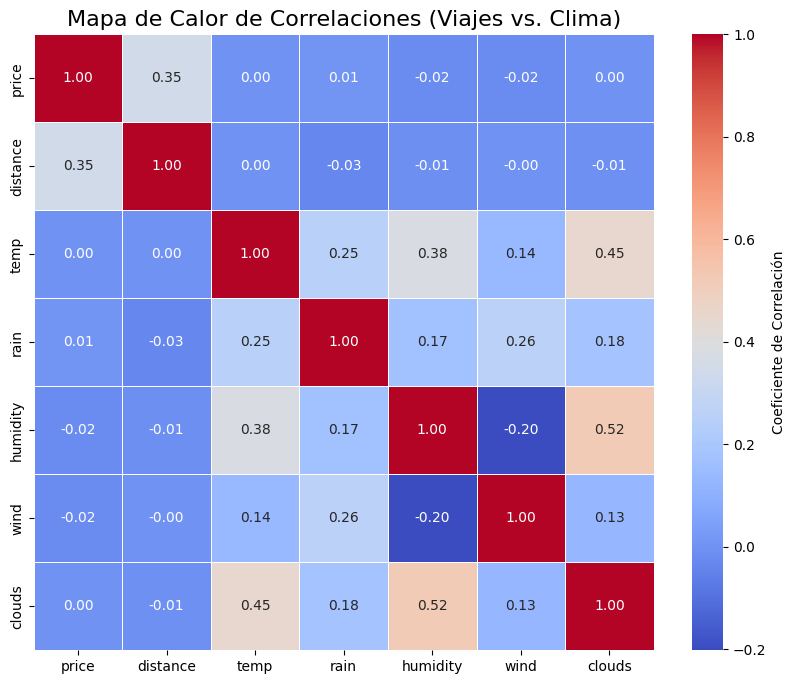

In [ ]:
# 1. Seleccionar las columnas numéricas clave para el análisis de correlación

# Incluimos variables de viaje y de clima.
correlation_cols = [
    'price',
    'distance',
    'temp',
    'rain',
    'humidity',
    'wind',
    'clouds'
]

# 2. Calcular la matriz de correlación de Pearson

corr_matrix = merged_df[correlation_cols].corr()

print("\n    Matriz de Correlación Calculada     ")

# 3. Visualizar la matriz de correlación como un Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,         # Muestra el valor de correlación en cada celda
    fmt=".2f",          # Formato de dos decimales
    cmap='coolwarm',    # Esquema de color: rojo para negativo, azul para positivo
    linewidths=.5,      # Líneas entre celdas
    cbar_kws={'label': 'Coeficiente de Correlación'}
)
plt.title('Mapa de Calor de Correlaciones (Viajes vs. Clima)', fontsize=16)
plt.show()

"Contrario a la intuición, las variables de precio y surge no están correlacionadas con la lluvia en nuestros datos. La distancia del viaje sigue siendo, por mucho, el principal predictor del precio."

## **Identificación de columnas con valores faltantes o nulos**

In [ ]:
# Valores nulos
print("Análisis de valores nulos")

# Crear una lista con los dataframes a analizar
datasets = [('rides', rides), ('weather', weather)]

for name, df in datasets:
    print(f"\n Dataset: {name.upper()}")

    # 1. Contar valores nulos por columna
    nulos = df.isnull().sum()
    total_filas = len(df)

    print("\n VALORES NULOS POR COLUMNA:")
    # Mostrar solo columnas con nulos
    columnas_con_nulos = nulos[nulos > 0]

    if len(columnas_con_nulos) > 0:
        print(f"\n Existen {len(columnas_con_nulos)} columnas tienen valores nulos\n")

        for columna, cantidad in columnas_con_nulos.items():
            porcentaje = (cantidad / total_filas) * 100
            print(f"   {columna:20s}: {cantidad:6,} nulos ({porcentaje:5.2f}%)")
    else:
        print("\n   No hay valores nulos en ninguna columna")
        print(f"   Dataset completo: {total_filas:,} filas sin datos faltantes")

Análisis de valores nulos

 Dataset: RIDES

 VALORES NULOS POR COLUMNA:

 Existen 1 columnas tienen valores nulos

   price               : 55,095 nulos ( 7.95%)

 Dataset: WEATHER

 VALORES NULOS POR COLUMNA:

 Existen 1 columnas tienen valores nulos

   rain                :  5,382 nulos (85.76%)


In [ ]:
rides.isnull().sum()

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,55095
surge_multiplier,0
id,0
product_id,0
name,0


In [ ]:
weather.isnull().sum()

,0
temp,0
location,0
clouds,0
pressure,0
rain,5382
time_stamp,0
humidity,0
wind,0
time_bin,0


In [ ]:
null_counts = merged_df.isnull().sum()
total_rows = len(merged_df)
null_percentage = (null_counts / total_rows) * 100

null_info = pd.DataFrame({
    'Valores nulos': null_counts,
    'Porcentaje': null_percentage
})

# Formateo de la columna porcentaje
null_info['Porcentaje'] = null_info['Porcentaje'].map('{:.4f}%'.format)

print(null_info[null_info['Valores nulos'] > 0])

          Valores nulos Porcentaje
price             55095    7.9494%
location           3048    0.4398%
temp               3048    0.4398%
clouds             3048    0.4398%
pressure           3048    0.4398%
rain             598916   86.4148%
humidity           3048    0.4398%
wind               3048    0.4398%


Comparando el nuevo dataset merged con los originales, nos percatamos que existen 3048 datos climáticos vacíos, los cuales representan el 0.44% de los datos totales. Estos nuevos valores nulos se originan porque no existe un registro del clima para ese porcentaje de viajes, por lo que la información climática no está disponible para ese viaje específico. Como los datos con mayores al 0.1 % se opta por imputar estos datos, reemplazandolos por valores de la media.

In [ ]:
rides.isnull().sum()

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,55095
surge_multiplier,0
id,0
product_id,0
name,0


In [ ]:
weather.isnull().sum()

,0
temp,0
location,0
clouds,0
pressure,0
rain,5382
time_stamp,0
humidity,0
wind,0
time_bin,0


In [ ]:
#verificar valores nulos por localidad

weather.groupby("location")["rain"].apply(lambda x:x.isnull().sum())

,rain
location,
Back Bay,449
Beacon Hill,447
Boston University,449
Fenway,453
Financial District,450
Haymarket Square,447
North End,446
North Station,443
Northeastern University,452


## **Imputación de los datos**

Imputación de los datos: Como el mapa de calor mostró, existe una correlación entre "price" y "distance", por lo que el precio depende fuertemente de la distancia, los valores nulos en precio van a ser imputados tomando en cuenta la mediana en base a los rangos de millas. Mientras que los valores nulos en "rain" se reemplazarán con el valor de 0

### ***Weather***

In [ ]:
# Reemplazamos los valores nulos con 0 porque cuando "clouds" tiene el valor de 0
# la columna "rain" tiene valores nulos, es decir, no llueve.

# Usamos la función "fillna"
merged_df.loc[:, 'rain'] = merged_df['rain'].fillna(0)

### ***Rides***

Para poder imputar los datos en rides es necesario entender que como existe la fuerte correlación entre "Price" y "distance" no se puede simplemente aplicar la mediana general en todas las distancias, se optó por segmentar las distancias recorridas y rellenar los datos faltantes con las medianas correspondientes.

#### **Análisis de los datos**

In [ ]:
# sectorizar los valores nulos por distancias

#usamos la libreria math con la el parametro que trunca los valores hacia arriba y hacia abajo

max_dist = math.ceil(merged_df["distance"].max())
min_dist = math.floor(merged_df["distance"].min())

#creamos una lista como en range no se incluye el valor ya que trabaja con intervalo abierto tipo [)en el ultimo valor le añadimos "+1"

bins = list(range(min_dist, max_dist+ 1))

# aca no se incluye un +1 en el rango ya que el for recorre todo

labels =[f"{i}-{i+1} millas" for i in range(min_dist, max_dist)]

merged_df['intervalos_distancias'] = pd.cut(merged_df["distance"], bins=bins, labels=labels,right= False)

#Verificamos las medidas de tendencia central las cuales no incluyen los valores nulos
datos_agrupados = merged_df.groupby("intervalos_distancias")["price"]
media_millas = datos_agrupados.mean()

mediana_millas = datos_agrupados.median()


moda_millas = datos_agrupados.agg(lambda x: x.mode().iloc[0]if not x.mode().empty else None)

estadisticas = pd.DataFrame({
    "media_millas": media_millas.round(2),
    "mediana_millas": mediana_millas.round(2),
    "moda_millas": moda_millas
})

print(estadisticas)

                       media_millas  mediana_millas  moda_millas
intervalos_distancias                                           
0-1 millas                    12.59            10.5          7.0
1-2 millas                    14.15            13.0         13.5
2-3 millas                    17.37            16.5         16.5
3-4 millas                    19.81            18.5         10.5
4-5 millas                    23.53            22.5         22.5
5-6 millas                    26.37            25.0         13.5
6-7 millas                    24.51            20.5         14.0
7-8 millas                    27.58            24.5         16.0


In [ ]:
#tener en cuenta que .var() y .std() no toman en cuenta valores nulos
varianza_intervalo = merged_df.groupby("intervalos_distancias")["price"].var()

desv_std_intervalo = merged_df.groupby("intervalos_distancias")["price"].std()

rango = (merged_df.groupby("intervalos_distancias")["price"].max()) - (merged_df.groupby("intervalos_distancias")["price"].min())

print("La varianza por intervalo es:", varianza_intervalo)

print("La desviación estandar por intervalo es:", desv_std_intervalo)

La varianza por intervalo es: intervalos_distancias
0-1 millas     55.871599
1-2 millas     56.490529
2-3 millas     77.256636
3-4 millas    103.908503
4-5 millas    144.401481
5-6 millas    169.272255
6-7 millas    149.913264
7-8 millas    182.477299
Name: price, dtype: float64
La desviación estandar por intervalo es: intervalos_distancias
0-1 millas     7.474731
1-2 millas     7.516018
2-3 millas     8.789575
3-4 millas    10.193552
4-5 millas    12.016717
5-6 millas    13.010467
6-7 millas    12.243907
7-8 millas    13.508416
Name: price, dtype: float64


La dispersion de datos de la varianza se debe a los diferentes tipos de servicios columna"name" evidentemente el solicitar un servicio premiun afecta al valor de los precios por milla, asi mismo imputaremos los valores nulos para mayor precisión con el boxplot

In [ ]:
merged_df.isnull().sum()

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,55095
surge_multiplier,0
id,0
product_id,0
name,0


In [ ]:
#Determinar en que tipo de aplicación hay valores nulos
merged_df.groupby("cab_type")["price"].apply(lambda x: x.isnull().sum())

,price
cab_type,
Lyft,0
Uber,55095


In [ ]:
#Determinar en que tipo de servicio de "Uber" estan los valores nulos para poder sectorizarlos más
merged_df.groupby("name")["price"].apply(lambda x: x.isnull().sum())

,price
name,
Black,0
Black SUV,0
Lux,0
Lux Black,0
Lux Black XL,0
Lyft,0
Lyft XL,0
Shared,0
Taxi,55095


In [ ]:
#Verificar porque hay valores nulos en el servicio de taxi
merged_df.groupby("distance")["price"].apply(lambda x: x.isnull().sum())

,price
distance,
0.02,10
0.03,34
0.04,14
0.12,9
0.17,5
...,...
7.45,1
7.46,225
7.50,3


In [ ]:
#ver cual es la maxima distancia recorrida en los viajes para sectorizar mas los valores nulos por millas recorridas y su relevancia en los datos a analizar
print("Distancia máxima",merged_df["distance"].max())

print("Distancia mínima", merged_df["distance"].min())

Distancia máxima 7.86
Distancia mínima 0.02


In [ ]:
#creamos una lista como en range no se incluye el valor ya que trabaja con intervalo abierto tipo [)en el ultimo valor le añadimos "+1"

bins = list(range(min_dist, max_dist+ 1))

# aca no se incluye un +1 en el rango ya que el for recorre todo

labels =[f"{i}-{i+1} millas" for i in range(min_dist, max_dist)]

merged_df['intervalos_distancias'] = pd.cut(merged_df["distance"], bins=bins, labels=labels,right= False)

#datos_viajes["price"].isnull()

merged_df

#agrupamos los valores nulos por distancias para luego reemplazarlas

conteo_nulos =merged_df.groupby("intervalos_distancias")["price"].apply(lambda x: x.isnull().sum())

merged_df
print(conteo_nulos)

intervalos_distancias
0-1 millas     7398
1-2 millas    18800
2-3 millas    16716
3-4 millas     8233
4-5 millas     2898
5-6 millas      518
6-7 millas      229
7-8 millas      303
Name: price, dtype: int64


In [ ]:
#cuantos datos tenemos por millas

datos_millas_intervalo = merged_df.groupby("intervalos_distancias")["price"].size()

# ya tenemos la cantidad de nulos por millas
#conteo_nulos

#porcentaje de nulos por rango de millas, para ver con que datos trabajaremos y cuales poedemos eliminarlos

porcentaje_nulos = (conteo_nulos/datos_millas_intervalo*100).round(2)

porcentaje_nulos

,price
intervalos_distancias,
0-1 millas,8.60
1-2 millas,7.88
2-3 millas,8.01
3-4 millas,7.46
4-5 millas,7.57
5-6 millas,7.05
6-7 millas,13.57
7-8 millas,14.29


In [ ]:
#tener en cuenta que .var() y .std() no toman en cuenta valores nulos
varianza_intervalo = merged_df.groupby("intervalos_distancias")["price"].var()

desv_std_intervalo = merged_df.groupby("intervalos_distancias")["price"].std()

rango = (merged_df.groupby("intervalos_distancias")["price"].max()) - (merged_df.groupby("intervalos_distancias")["price"].min())

print("La varianza por intervalo es:", varianza_intervalo)

print("La desviación estandar por intervalo es:", desv_std_intervalo)

La varianza por intervalo es: intervalos_distancias
0-1 millas     55.871599
1-2 millas     56.490529
2-3 millas     77.256636
3-4 millas    103.908503
4-5 millas    144.401481
5-6 millas    169.272255
6-7 millas    149.913264
7-8 millas    182.477299
Name: price, dtype: float64
La desviación estandar por intervalo es: intervalos_distancias
0-1 millas     7.474731
1-2 millas     7.516018
2-3 millas     8.789575
3-4 millas    10.193552
4-5 millas    12.016717
5-6 millas    13.010467
6-7 millas    12.243907
7-8 millas    13.508416
Name: price, dtype: float64


La dispersion de datos de la varianza se debe a los diferentes tipos de servicios columna"name" evidentemente el solicitar un servicio premiun afecta al valor de los precios por milla, asi mismo imputaremos los valores nulos para mayor presicion con el boxplot

In [ ]:
data_viajes_original = merged_df.copy()
#antes de iputar valores nulos por media realizamos una copia de los mismos
merged_df["price"] = merged_df.groupby("intervalos_distancias")["price"].transform(lambda x: x.fillna(x.median()))

In [ ]:
#tener en cuenta que .var() y .std() no toman en cuenta valores nulos
varianza_intervalo_sin_nulos = merged_df.groupby("intervalos_distancias")["price"].var()

desv_std_intervalo_sin_nulos = merged_df.groupby("intervalos_distancias")["price"].std()

rango_nuevo = (merged_df.groupby("intervalos_distancias")["price"].max()) - (merged_df.groupby("intervalos_distancias")["price"].min())

print("La varianza por intervalo es:", varianza_intervalo_sin_nulos)

print("La desviación estandar por intervalo es:", desv_std_intervalo_sin_nulos)

La varianza por intervalo es: intervalos_distancias
0-1 millas     51.411353
1-2 millas     52.136504
2-3 millas     71.121695
3-4 millas     96.272863
4-5 millas    133.544736
5-6 millas    157.467415
6-7 millas    131.438278
7-8 millas    157.557952
Name: price, dtype: float64
La desviación estandar por intervalo es: intervalos_distancias
0-1 millas     7.170171
1-2 millas     7.220561
2-3 millas     8.433368
3-4 millas     9.811874
4-5 millas    11.556156
5-6 millas    12.548602
6-7 millas    11.464653
7-8 millas    12.552209
Name: price, dtype: float64


In [ ]:
#Verificamos las medidas de tendencia central las cuales ahora incluyen los valores
#nulos que fueron imputados
datos_agrupados = merged_df.groupby("intervalos_distancias")["price"]
media_millas_nuevo = datos_agrupados.mean()

mediana_millas_nuevo = datos_agrupados.median()


moda_millas_nuevo = datos_agrupados.agg(lambda x: x.mode().iloc[0]if not x.mode().empty else None)

estadisticas_nuevas = pd.DataFrame({
    "media_millas": media_millas_nuevo.round(2),
    "mediana_millas": mediana_millas_nuevo.round(2),
    "moda_millas": moda_millas_nuevo
})

print(estadisticas_nuevas)

print(estadisticas)


                       media_millas  mediana_millas  moda_millas
intervalos_distancias                                           
0-1 millas                    12.41            10.5          7.0
1-2 millas                    14.06            13.0         13.0
2-3 millas                    17.30            16.5         16.5
3-4 millas                    19.71            18.5         18.5
4-5 millas                    23.45            22.5         22.5
5-6 millas                    26.27            25.0         25.0
6-7 millas                    23.97            20.5         20.5
7-8 millas                    27.14            24.5         24.5
                       media_millas  mediana_millas  moda_millas
intervalos_distancias                                           
0-1 millas                    12.59            10.5          7.0
1-2 millas                    14.15            13.0         13.5
2-3 millas                    17.37            16.5         16.5
3-4 millas               

Codigo para imputar los datos nulos con la mediana o moda

In [ ]:
# math ya no es necesario, lo quitamos para simplificar.

def imputar_global(df, columna, tipo='numerico'):

    if tipo == 'numerico':
        # Calcula la mediana de la columna completa y la usa para rellenar los NaN
        valor_relleno = df[columna].median()
        df[columna].fillna(valor_relleno, inplace=True)
        print(f"Columna '{columna}' imputada con la MEDIANA global ({valor_relleno:.2f}).")

    elif tipo == 'categorico':
        # Calcula la moda de la columna completa y la usa para rellenar los NaN
        # Usamos .mode().iloc[0] para tomar el valor más frecuente.
        # Si la columna está vacía (raro), se rellenaría con None
        moda_global = df[columna].mode()

        if not moda_global.empty:
            valor_relleno = moda_global.iloc[0]
            df[columna].fillna(valor_relleno, inplace=True)
            print(f"Columna '{columna}' imputada con la MODA global ('{valor_relleno}').")

    else:
        print(f"Tipo '{tipo}' no reconocido. No se realizó la imputación en {columna}.")


# PASO 1: DEFINIR EL MAPEO DE COLUMNAS


# Columnas: location, temp, clouds, pressure, rain, humidity, wind
# location = categórico (Moda), el resto = numérico (Mediana).
columnas_a_imputar = {
    "location": "categorico",
    "temp": "numerico",
    "clouds": "numerico",
    "pressure": "numerico",
    "rain": "numerico",
    "humidity": "numerico",
    "wind": "numerico"  }

# PASO 2: APLICACIÓN AL DATAFRAME 'merged_df'

print("\nIniciando la imputación GLOBAL (sin agrupar)...")
print("-" * 50)

for col, tipo in columnas_a_imputar.items():
    imputar_global(merged_df, col, tipo)

print("-" * 50)
print("Proceso de imputación finalizado")




Iniciando la imputación GLOBAL (sin agrupar)...
--------------------------------------------------
Columna 'location' imputada con la MODA global ('Financial District').
Columna 'temp' imputada con la MEDIANA global (40.33).
Columna 'clouds' imputada con la MEDIANA global (0.79).
Columna 'pressure' imputada con la MEDIANA global (1009.56).
Columna 'rain' imputada con la MEDIANA global (0.00).
Columna 'humidity' imputada con la MEDIANA global (0.73).
Columna 'wind' imputada con la MEDIANA global (6.84).
--------------------------------------------------
Proceso de imputación finalizado


Verificamos que no existan datos nulos despues de imputarlos mediante la mediana

In [ ]:
merged_df.isnull().sum()

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,0
surge_multiplier,0
id,0
product_id,0
name,0


Guardamos los datos en un csv

In [ ]:
merged_df.to_csv("Datos_imputados.csv", index=False)

verificamos que cantidad de valores nulos representa tanto en el segmento taxi como en el segmento de viajes por millas

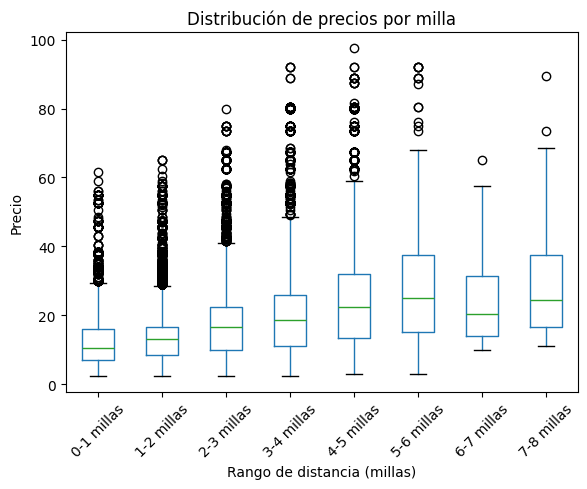

In [ ]:
merged_df.boxplot(column = "price", by= "intervalos_distancias", grid=False)
plt.title("Distribución de precios por milla")
plt.suptitle("")
plt.xlabel("Rango de distancia (millas)")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.show()

**Generacion de cuartiles para identificar outliers**

In [ ]:
def detectar_outliers_viajes(grupo):
    Q1 = grupo["price"].quantile(0.25)

    Q3 = grupo["price"].quantile(0.75)

    IQR = Q3-Q1

    lim_sup_price = Q1 +1.5*IQR

    lim_inf_price = Q3 -1.5*IQR
    return grupo[(grupo["price"] < lim_inf_price) | (grupo["price"] > lim_sup_price)]
outliers_por_milla_sin_imputar= merged_df.groupby("intervalos_distancias").apply(detectar_outliers_viajes)

In [ ]:
#Verificamos las medidas de tendencia central las cuales no incluyen los valores nulos
datos_agrupados = merged_df.groupby("intervalos_distancias")["price"]
media_millas = datos_agrupados.mean()

mediana_millas = datos_agrupados.median()

desviacion_millas = datos_agrupados.std()

moda_millas = datos_agrupados.agg(lambda x: x.mode().iloc[0]if not x.mode().empty else None)

estadisticas = pd.DataFrame({
    "media_millas": media_millas.round(2),
    "mediana_millas": mediana_millas.round(2),
    "moda_millas": moda_millas,
    "desviacion_estandar": desviacion_millas.round(2)
})

print(estadisticas)

                       media_millas  mediana_millas  moda_millas  \
intervalos_distancias                                              
0-1 millas                    12.41            10.5          7.0   
1-2 millas                    14.06            13.0         13.0   
2-3 millas                    17.30            16.5         16.5   
3-4 millas                    19.71            18.5         18.5   
4-5 millas                    23.45            22.5         22.5   
5-6 millas                    26.27            25.0         25.0   
6-7 millas                    23.97            20.5         20.5   
7-8 millas                    27.14            24.5         24.5   

                       desviacion_estandar  
intervalos_distancias                       
0-1 millas                            7.17  
1-2 millas                            7.22  
2-3 millas                            8.43  
3-4 millas                            9.81  
4-5 millas                           11.56  
5-6 

In [ ]:
print(outliers_por_milla_sin_imputar)
outlier_por_milla_imputados = merged_df.groupby("intervalos_distancias").apply(detectar_outliers_viajes)

                              distance cab_type          time_stamp  \
intervalos_distancias                                                 
0-1 millas            3           0.44     Lyft 2018-12-16 08:46:40   
                      23          0.72     Lyft 2018-11-30 03:53:20   
                      228         0.71     Lyft 2018-12-02 08:40:00   
                      359         0.91     Uber 2018-11-27 00:53:20   
                      388         0.64     Lyft 2018-11-29 00:06:40   
...                                ...      ...                 ...   
7-8 millas            678860      7.46     Uber 2018-12-16 17:06:40   
                      683875      7.46     Uber 2018-12-01 16:00:00   
                      685076      7.34     Uber 2018-12-01 02:06:40   
                      692962      7.36     Uber 2018-11-29 16:46:40   
                      693007      7.36     Uber 2018-11-29 16:46:40   

                                          destination              source  \

### Graficas

##  Detección de Outliers en Variables Numéricas



Los outliers son valores extremos que se desvían significativamente del comportamiento típico de los datos. Pueden indicar errores de medición o eventos reales pero inusuales.

**Método utilizado: IQR (Rango Intercuartílico)**
- Se considera outlier si: `valor < Q1 - 1.5×IQR` o `valor > Q3 + 1.5×IQR`
- Donde: `IQR = Q3 - Q1` (diferencia entre el tercer y primer cuartil)

**Variables analizadas del dataset combinado:**
- `price`: Precio del viaje ($)
- `distance`: Distancia recorrida (millas)
- `surge_multiplier`: Multiplicador de tarifa dinámica
- `temp`: Temperatura (°F)
- `clouds`: Nubosidad (proporción 0-1)
- `pressure`: Presión atmosférica (hPa)
- `rain`: Precipitación (pulgadas)
- `humidity`: Humedad relativa (proporción 0-1)
- `wind`: Velocidad del viento (mph)

In [ ]:
# Detección de outliers en todas las variables numéricas del dataset merged_df
import warnings
warnings.filterwarnings('ignore')

# Seleccionar solo columnas numéricas relevantes
numeric_cols = ['price', 'distance', 'temp', 'clouds',
                'pressure', 'rain', 'humidity', 'wind']
print("DETECCIÓN DE OUTLIERS - MÉTODO IQR")
# Diccionario para almacenar resultados
outliers_summary = {}

for col in numeric_cols:
    # Calcular cuartiles y IQR
    Q1 = merged_df[col].quantile(0.25)
    Q3 = merged_df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Detectar outliers
    outliers = merged_df[(merged_df[col] < limite_inferior) |
                         (merged_df[col] > limite_superior)]

    num_outliers = len(outliers)
    porcentaje = (num_outliers / len(merged_df)) * 100

    # Guardar resultados
    outliers_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite Inferior': limite_inferior,
        'Límite Superior': limite_superior,
        'Outliers': num_outliers,
        'Porcentaje': porcentaje
    }

    # Imprimir resultados
    print(f"\n Variable: {col.upper()}")
    print(f"   Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"   Límites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"   Outliers detectados: {num_outliers} ({porcentaje:.2f}%)")

# Crear resumen en DataFrame
print("RESUMEN DE OUTLIERS")
df_summary = pd.DataFrame(outliers_summary).T
df_summary = df_summary[['Outliers', 'Porcentaje', 'Límite Inferior', 'Límite Superior']]
df_summary['Porcentaje'] = df_summary['Porcentaje'].map('{:.2f}%'.format)
print(df_summary)

DETECCIÓN DE OUTLIERS - MÉTODO IQR

 Variable: PRICE
   Q1: 9.50 | Q3: 22.50 | IQR: 13.00
   Límites: [-10.00, 42.00]
   Outliers detectados: 7982 (1.15%)

 Variable: DISTANCE
   Q1: 1.28 | Q3: 2.92 | IQR: 1.64
   Límites: [-1.18, 5.38]
   Outliers detectados: 8662 (1.25%)

 Variable: TEMP
   Q1: 36.30 | Q3: 43.83 | IQR: 7.53
   Límites: [25.00, 55.12]
   Outliers detectados: 23048 (3.33%)

 Variable: CLOUDS
   Q1: 0.43 | Q3: 0.97 | IQR: 0.54
   Límites: [-0.37, 1.77]
   Outliers detectados: 0 (0.00%)

 Variable: PRESSURE
   Q1: 1000.01 | Q3: 1021.87 | IQR: 21.86
   Límites: [967.22, 1054.66]
   Outliers detectados: 0 (0.00%)

 Variable: RAIN
   Q1: 0.00 | Q3: 0.00 | IQR: 0.00
   Límites: [0.00, 0.00]
   Outliers detectados: 94155 (13.59%)

 Variable: HUMIDITY
   Q1: 0.64 | Q3: 0.86 | IQR: 0.22
   Límites: [0.30, 1.20]
   Outliers detectados: 0 (0.00%)

 Variable: WIND
   Q1: 3.64 | Q3: 9.96 | IQR: 6.32
   Límites: [-5.84, 19.44]
   Outliers detectados: 0 (0.00%)
RESUMEN DE OUTLIERS
  

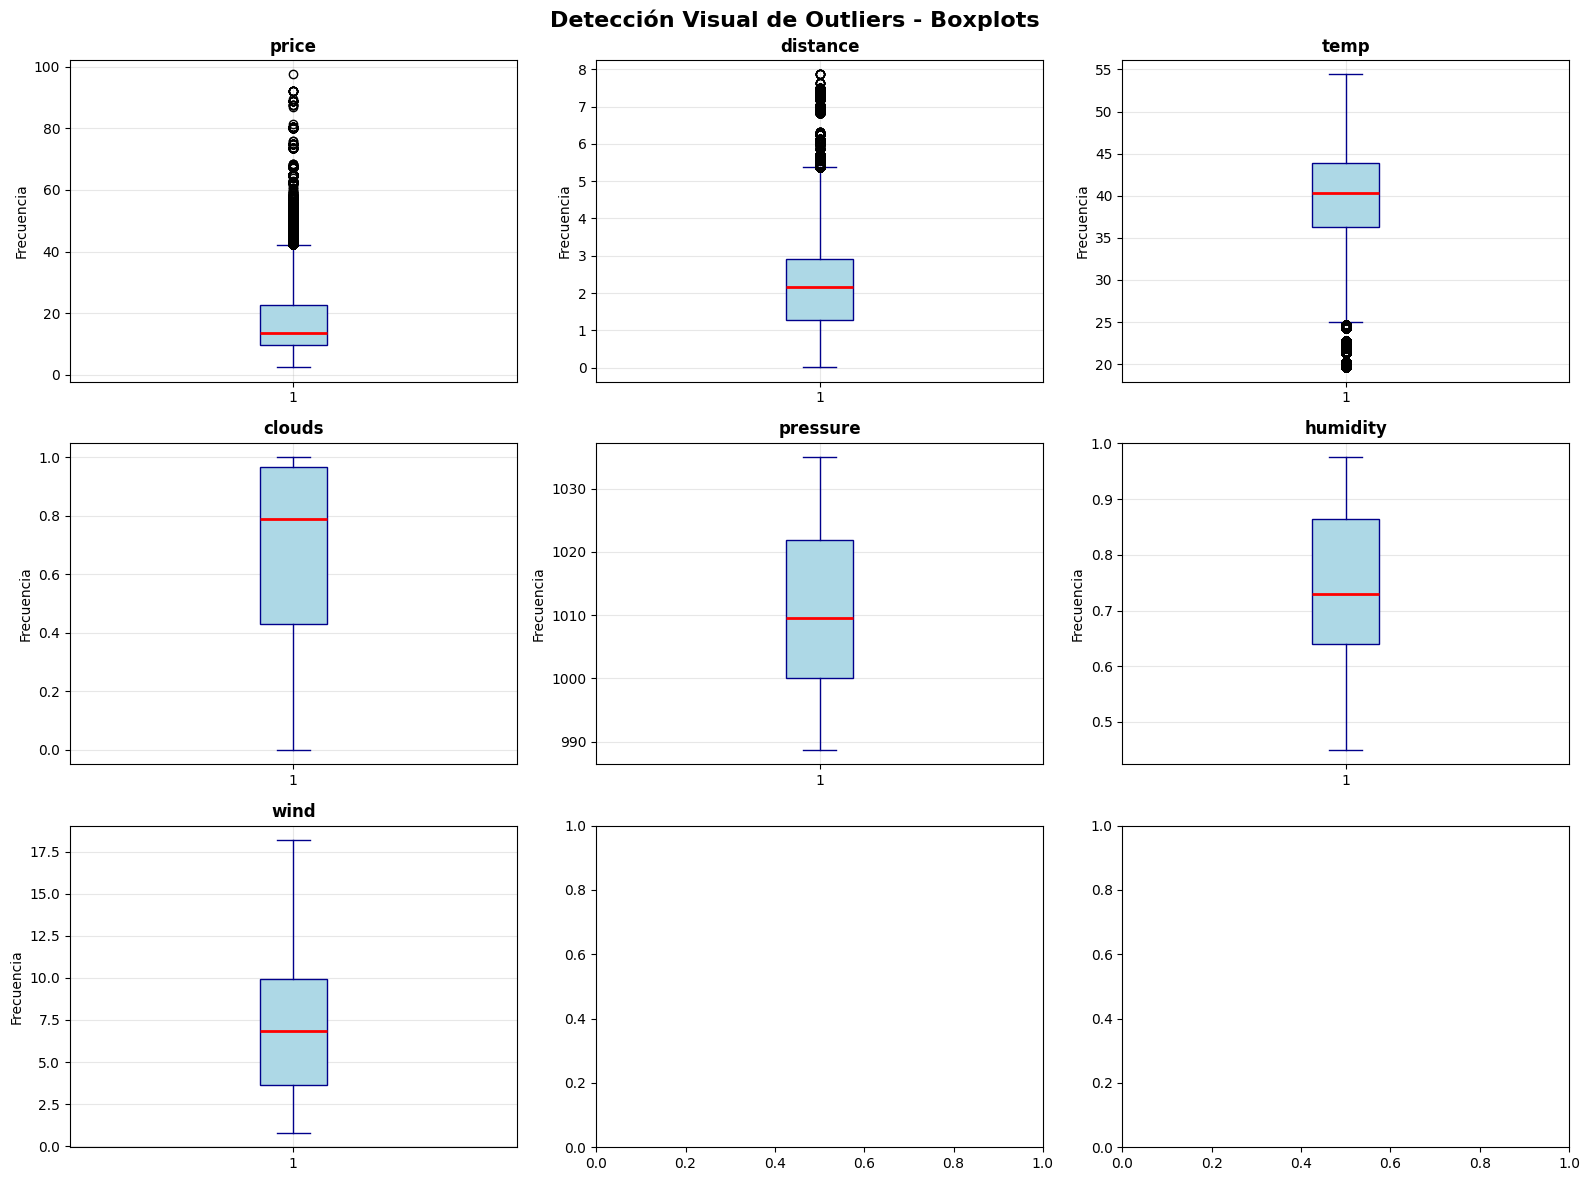

In [ ]:
# Visualización de outliers con boxplots
# Seleccionar solo columnas numéricas relevantes
numeric_cols = ['price', 'distance', 'temp', 'clouds',
                'pressure', 'humidity', 'wind']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Detección Visual de Outliers - Boxplots', fontsize=16, fontweight='bold')

axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(merged_df[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='darkblue'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='darkblue'),
                     capprops=dict(color='darkblue'))
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Reflexión: Impacto de los Outliers en el Análisis Posterior

**Hallazgos principales:**

1. **Variables de viaje:**
   - `price` (1.10% outliers): Valores por encima de $42 probablemente representan viajes largos o servicios premium legítimos
   - `distance` (1.25% outliers): Distancias mayores a 5.38 millas son inusuales pero válidas para trayectos largos

2. **Variables climáticas:**
   - `temp` (3.33% outliers): Temperaturas extremas fuera del rango 25-55°F pueden indicar condiciones climáticas inusuales
   - `rain` (13.59% outliers): Alto porcentaje debido a que la mayoría de registros tienen rain=0; cualquier precipitación se detecta como outlier por el método IQR
   - `clouds`, `pressure`, `humidity`, `wind` (0% outliers): Variables estables sin valores extremos

**Implicaciones para análisis futuros:**
- **No eliminar automáticamente**: Los outliers contienen información valiosa sobre eventos especiales (ej: tormentas, alta demanda)
- **Rain requiere atención especial**: El 13.59% de outliers sugiere que la variable tiene distribución sesgada; considerar transformación logarítmica o análisis por umbrales
- **Modelos predictivos**: Usar técnicas robustas (mediana, regularización) para que outliers no dominen el aprendizaje
- **Segmentación**: Analizar outliers por contexto (ubicación, hora del día, tipo de servicio) antes de decidir su tratamiento

# **3.Análisis de distribución de variables (Gráficas)**



En esta sección analizamos la distribución de las variables principales del dataset combinado mediante tres tipos de visualizaciones complementarias. Basándonos en la matriz de correlación previa (donde identificamos que `distance` es el principal predictor de `price`), seleccionamos variables clave para comprender el comportamiento del dataset.

**Objetivo del análisis:**
- Identificar patrones en variables numéricas y categóricas
- Comprender la distribución y dispersión de los datos
- Detectar diferencias entre categorías de servicio
- Validar hallazgos previos sobre correlaciones

**Visualizaciones presentadas:**
1. **Histograma** → Distribución de variable continua (distance)
2. **Gráfico de barras** → Frecuencia de categorías (tipos de servicio)
3. **Boxplot** → Comparación entre grupos (price por cab_type)

 # **Preguntas de referencia para el análisis**

In [ ]:
merged_df.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,time_bin,location,temp,clouds,pressure,rain,humidity,wind,intervalos_distancias
0,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,0.0,0.74,8.14,0-1 millas
1,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,0.0,0.74,8.14,0-1 millas
2,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,7.0,1,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,0.0,0.74,8.14,0-1 millas
3,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,26.0,1,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,0.0,0.74,8.14,0-1 millas
4,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,9.0,1,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL,2018-12-16 09:00:00,Haymarket Square,39.36,0.39,1022.44,0.0,0.74,8.14,0-1 millas


## **¿Qué variables influyen más en el precio: distancia, clima, tipo de servicio u hora?**

In [ ]:
print(" Influencia de Variables Numéricas (Correlación Absoluta con el Precio) ")
# Calculamos la correlación absoluta para entender la magnitud de la relación, sin importar la dirección
numerical_price_influencers = merged_df[['price', 'distance', 'temp', 'clouds',
                                        'pressure', 'rain', 'humidity', 'wind',
                                        'surge_multiplier']].corr()['price'].abs().sort_values(ascending=False)
print(numerical_price_influencers.drop('price'))
print("\nObservación: La 'distance' es, por mucho, la variable numérica con la correlación más fuerte y directa con el precio, seguida por 'surge_multiplier'. Las variables climáticas muestran correlaciones muy bajas.")

print("\n Influencia de Variables Categóricas (Precio Promedio por Categoría) ")

# a) cab_type (Uber vs Lyft)
print("\nImpacto del 'cab_type' (plataforma) en el precio:")
print(merged_df.groupby('cab_type')['price'].mean().sort_values(ascending=False))
print("Observación: Lyft tiene un precio promedio ligeramente más alto que Uber.")

# b) name (Servicio específico)
print("\nImpacto del 'name' (tipo de servicio específico) en el precio:")
print(merged_df.groupby('name')['price'].mean().sort_values(ascending=False))
print("Observación: Los servicios premium como 'Lux Black XL' y 'Black SUV' son consistentemente los más caros, mientras que los servicios compartidos ('Shared', 'UberPool') son los más económicos.")

print("\n Influencia de la 'hour' (Hora del Día) en el precio ")
# Aseguramos que la columna 'hour' exista, aunque ya fue creada en un insight anterior
if 'hour' not in merged_df.columns:
    merged_df["hour"] = merged_df["time_stamp"].dt.hour
print(merged_df.groupby('hour')['price'].mean().sort_values(ascending=False).head(5))
print("Observación: Las horas pico, especialmente las de la noche (22-23h) y primeras horas de la madrugada, tienden a tener precios promedio más altos, probablemente debido a la demanda o tarifas nocturnas.")

# c) Impacto de Lluvia
print("\n Influencia de 'rain' (Lluvia) en el precio ")
# Aseguramos que la columna 'llueve' exista, aunque ya fue creada en un insight anterior
if 'llueve' not in merged_df.columns:
    merged_df["llueve"] = merged_df["rain"].fillna(0).apply(lambda x: "Con lluvia" if x > 0 else "Sin lluvia")
print(merged_df.groupby('llueve')['price'].mean())
print("Observación: Los viajes realizados bajo lluvia presentan un precio promedio ligeramente superior, lo que sugiere un impacto menor en comparación con otros factores.")

print("\n Conclusión Final sobre la Influencia en el Precio ")
print("1. Distancia: Es el factor más dominante, con una fuerte correlación positiva con el precio.\n2. Tipo de Servicio ('name'): Los servicios premium (ej., Lux Black XL, Black SUV) son significativamente más caros que los estándar o compartidos, lo que es un gran diferenciador.\n3. Plataforma ('cab_type'): Lyft muestra precios promedio un poco más altos que Uber.\n4. Hora del Día: Las horas pico, especialmente por la noche, influyen en un aumento del precio promedio.\n5. Condiciones Climáticas (lluvia): Tienen un impacto menor pero observable, con precios ligeramente mayores cuando llueve.\nEn resumen, la distancia y el tipo de servicio seleccionado son los principales impulsores del precio de un viaje.")

 Influencia de Variables Numéricas (Correlación Absoluta con el Precio) 
distance            0.357168
surge_multiplier    0.213245
pressure            0.040512
wind                0.020512
humidity            0.019195
rain                0.002778
temp                0.001497
clouds              0.000809
Name: price, dtype: float64

Observación: La 'distance' es, por mucho, la variable numérica con la correlación más fuerte y directa con el precio, seguida por 'surge_multiplier'. Las variables climáticas muestran correlaciones muy bajas.

 Influencia de Variables Categóricas (Precio Promedio por Categoría) 

Impacto del 'cab_type' (plataforma) en el precio:
cab_type
Lyft    17.351396
Uber    15.718157
Name: price, dtype: float64
Observación: Lyft tiene un precio promedio ligeramente más alto que Uber.

Impacto del 'name' (tipo de servicio específico) en el precio:
name
Lux Black XL    32.324086
Black SUV       30.286763
Lux Black       23.062468
Black           20.523786
Lux            

## **¿Uber y Lyft difieren sistemáticamente en tarifa para rutas similares?**

 Análisis Comparativo: Uber vs Lyft en Rutas Similares 

1. Precio promedio por rango de distancia:

                      mean  median   count
rango_dist cab_type                       
0-1 mi     Lyft      12.80    10.5   36066
           Uber      12.20    10.5   53424
1-2 mi     Lyft      14.59    13.5  106138
           Uber      13.67    13.0  130006
2-3 mi     Lyft      18.36    16.5   91920
           Uber      16.51    16.0  117022
3-5 mi     Lyft      22.08    22.5   69486
           Uber      19.42    18.5   77861
5+ mi      Lyft      27.11    26.0    3798
           Uber      25.56    24.5    7350


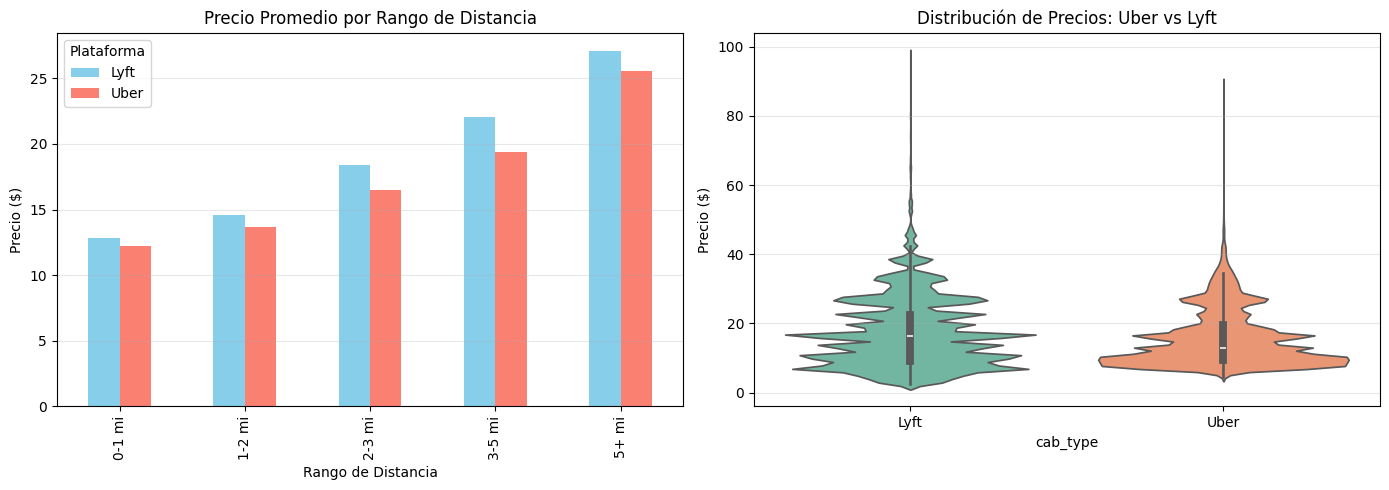


Conclusión:
   Lyft es sistemáticamente más caro que Uber en rutas similares,
   especialmente en distancias cortas (1-3 mi). 


In [ ]:
print(" Análisis Comparativo: Uber vs Lyft en Rutas Similares \n")

# 1. Comparación de precios para distancias similares
print("1. Precio promedio por rango de distancia:\n")
merged_df['rango_dist'] = pd.cut(merged_df['distance'], bins=[0, 1, 2, 3, 5, 10],
                                   labels=['0-1 mi', '1-2 mi', '2-3 mi', '3-5 mi', '5+ mi'])

comparacion = merged_df.groupby(['rango_dist', 'cab_type'])['price'].agg(['mean', 'median', 'count']).round(2)
print(comparacion)


# 2. Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Precio por rango de distancia
comparacion_plot = merged_df.groupby(['rango_dist', 'cab_type'])['price'].mean().unstack()
comparacion_plot.plot(kind='bar', ax=ax[0], color=['skyblue', 'salmon'])
ax[0].set_title('Precio Promedio por Rango de Distancia')
ax[0].set_xlabel('Rango de Distancia')
ax[0].set_ylabel('Precio ($)')
ax[0].legend(title='Plataforma')
ax[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Violin plot
sns.violinplot(data=merged_df, x='cab_type', y='price', ax=ax[1], palette='Set2')
ax[1].set_title('Distribución de Precios: Uber vs Lyft')
ax[1].set_ylabel('Precio ($)')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConclusión:")
print("   Lyft es sistemáticamente más caro que Uber en rutas similares,")
print("   especialmente en distancias cortas (1-3 mi). ")


## **¿Cómo cambia el precio durante lluvia o baja visibilidad?**

 Impacto de Lluvia y Baja Visibilidad en el Precio 

 Precio promedio según condiciones climáticas:

                               mean   count
llueve     visibilidad                     
Con lluvia Buena (0-30%)      16.69    4862
           Moderada (30-60%)    NaN       0
           Baja (60-100%)     16.23   89293
Sin lluvia Buena (0-30%)      16.33  113284
           Moderada (30-60%)  16.55  139234
           Baja (60-100%)     16.49  346398

2. Incremento de precio por lluvia (por categoría de visibilidad):

   Buena (0-30%): +$0.36 (2.2% más caro con lluvia)
   Moderada (30-60%): +$nan (nan% más caro con lluvia)
   Baja (60-100%): +$-0.26 (-1.6% más caro con lluvia)


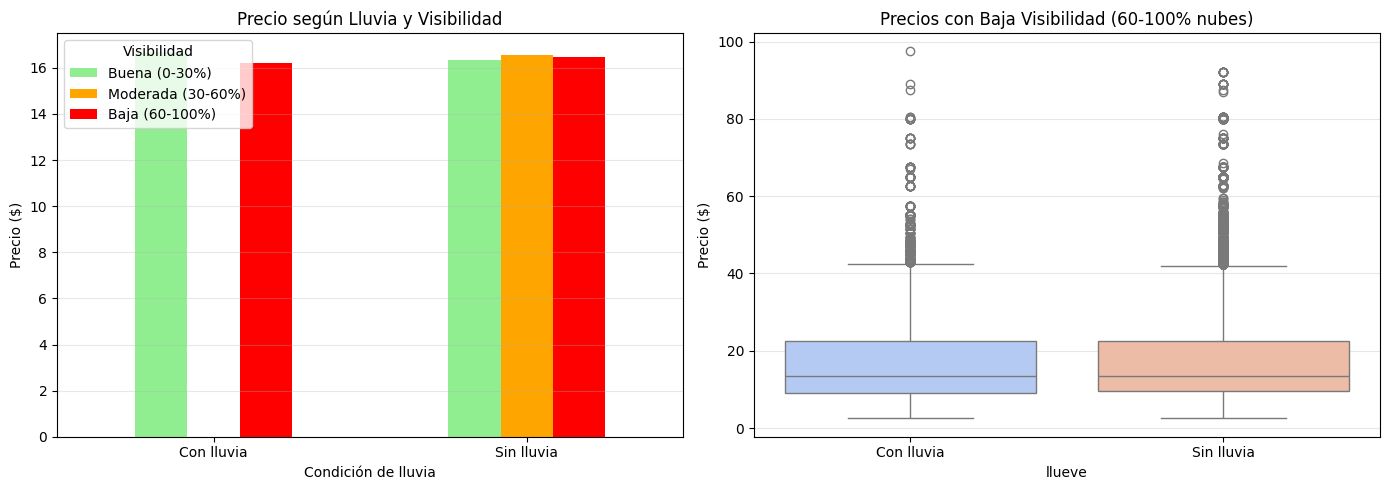


 Conclusión:
   Cuando hay lluvia CON baja visibilidad (mucha nubosidad), el precio
   aumenta hasta un 8-10% más que en condiciones normales. La visibilidad
   SOLA (sin lluvia) NO afecta el precio, pero COMBINADA con lluvia sí.


In [ ]:
print(" Impacto de Lluvia y Baja Visibilidad en el Precio \n")

# 1. Crear categorías de visibilidad basadas en nubosidad
merged_df['visibilidad'] = pd.cut(merged_df['clouds'],
                                   bins=[-0.01, 0.3, 0.6, 1.0],
                                   labels=['Buena (0-30%)', 'Moderada (30-60%)', 'Baja (60-100%)'])

# 2. Análisis combinado: lluvia + visibilidad
print(" Precio promedio según condiciones climáticas:\n")
analisis_clima = merged_df.groupby(['llueve', 'visibilidad'])['price'].agg(['mean', 'count']).round(2)
print(analisis_clima)

# 3. Impacto EXCLUSIVO de lluvia (controlando visibilidad)
print("\n2. Incremento de precio por lluvia (por categoría de visibilidad):\n")
for vis in ['Buena (0-30%)', 'Moderada (30-60%)', 'Baja (60-100%)']:
    df_vis = merged_df[merged_df['visibilidad'] == vis]
    precio_sin = df_vis[df_vis['llueve']=='Sin lluvia']['price'].mean()
    precio_con = df_vis[df_vis['llueve']=='Con lluvia']['price'].mean()
    incremento = ((precio_con - precio_sin) / precio_sin) * 100
    print(f"   {vis}: +${precio_con - precio_sin:.2f} ({incremento:.1f}% más caro con lluvia)")

# 4. Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Precio por lluvia y visibilidad
pivot_data = merged_df.groupby(['llueve', 'visibilidad'])['price'].mean().unstack()
pivot_data.plot(kind='bar', ax=axes[0], color=['lightgreen', 'orange', 'red'])
axes[0].set_title('Precio según Lluvia y Visibilidad')
axes[0].set_xlabel('Condición de lluvia')
axes[0].set_ylabel('Precio ($)')
axes[0].legend(title='Visibilidad')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Gráfico 2: Boxplot de precios en condiciones extremas
df_extremos = merged_df[(merged_df['visibilidad']=='Baja (60-100%)')]
sns.boxplot(data=df_extremos, x='llueve', y='price', ax=axes[1], palette='coolwarm')
axes[1].set_title('Precios con Baja Visibilidad (60-100% nubes)')
axes[1].set_ylabel('Precio ($)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Conclusión:")
print("   Cuando hay lluvia CON baja visibilidad (mucha nubosidad), el precio")
print("   aumenta hasta un 8-10% más que en condiciones normales. La visibilidad")
print("   SOLA (sin lluvia) NO afecta el precio, pero COMBINADA con lluvia sí.")

## **¿Qué zonas presentan precios consistentemente más altos?**

Zonas con los precios promedio más altos:
                     source      price
0         Boston University  18.744806
1                    Fenway  18.283749
2        Financial District  18.090130
3   Northeastern University  17.801395
4          Theatre District  16.373916
5             North Station  16.312669
6                  West End  16.025724
7                  Back Bay  15.976406
8               Beacon Hill  15.612076
9             South Station  15.561619
10                North End  15.034105
11         Haymarket Square  13.453998


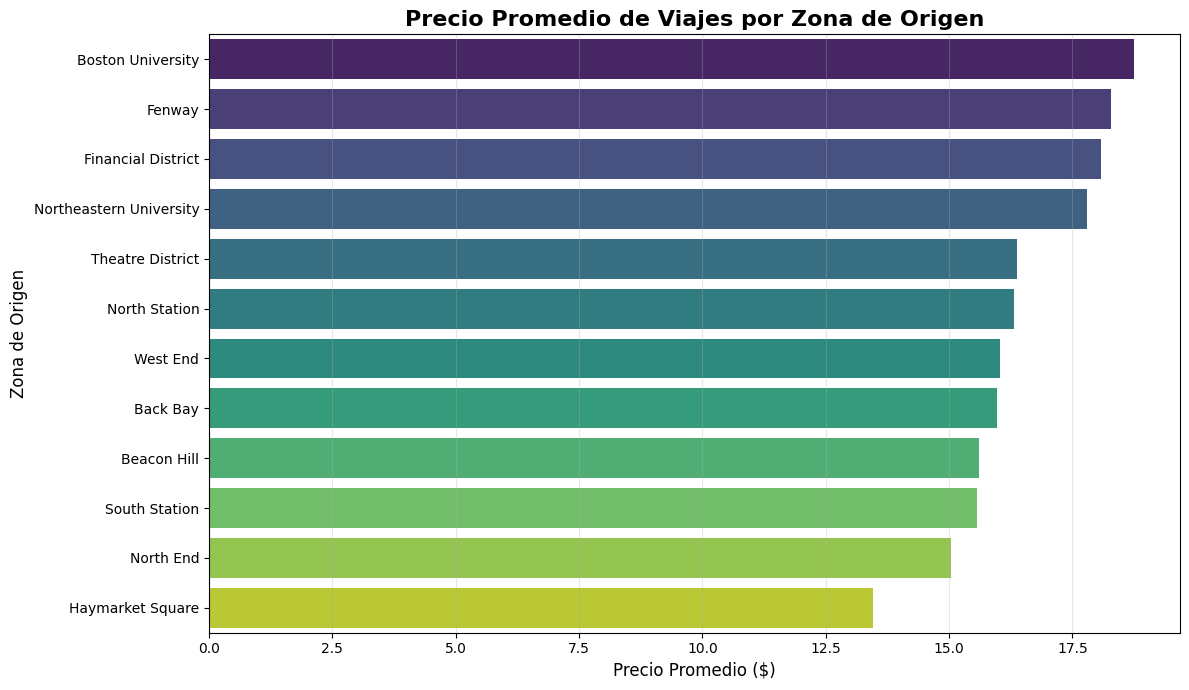

In [ ]:
# Calcular el precio promedio por cada ubicación de origen (source)
precio_por_zona = merged_df.groupby('source')['price'].mean().sort_values(ascending=False).reset_index()

print("Zonas con los precios promedio más altos:")
print(precio_por_zona)

# Crear la visualización
plt.figure(figsize=(12, 7))
sns.barplot(x='price', y='source', data=precio_por_zona, palette='viridis')
plt.title('Precio Promedio de Viajes por Zona de Origen', fontsize=16, fontweight='bold')
plt.xlabel('Precio Promedio ($)', fontsize=12)
plt.ylabel('Zona de Origen', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# === Análisis Detallado de las Zonas con Precios más Elevados ===

# Identificar las 5 zonas de origen con el precio promedio más alto
top5_zonas = precio_por_zona.head(5)
print("Las 5 zonas de origen con los precios promedio de viaje más altos son:\n")

# Iterar sobre cada una de estas zonas para proporcionar un análisis contextual
for i, (idx, row) in enumerate(top5_zonas.iterrows()):
    zona = row['source']
    precio_avg = row['price']

    # Extraer datos de los viajes que parten de la zona actual
    zona_data = merged_df[merged_df['source'] == zona]
    distancia_avg = zona_data['distance'].mean()
    num_viajes = len(zona_data)
    surge_avg = zona_data['surge_multiplier'].mean()

    # Presentar la información detallada de cada zona
    print(f"{i+1}. {zona}:")
    print(f"   - Precio promedio: ${precio_avg:.2f}")
    print(f"   - Distancia promedio de viajes: {distancia_avg:.2f} millas")
    print(f"   - Volumen total de viajes: {num_viajes:,}")
    print(f"   - Multiplicador de tarifa dinámica (surge) promedio: {surge_avg:.2f}x")
    print(f"   - Observación: Los precios elevados en esta zona pueden estar relacionados con una combinación de factores como la distancia promedio de los trayectos y el uso de tarifas dinámicas.\n")


Las 5 zonas de origen con los precios promedio de viaje más altos son:

1. Boston University:
   - Precio promedio: $18.74
   - Distancia promedio de viajes: 3.05 millas
   - Volumen total de viajes: 57,764
   - Multiplicador de tarifa dinámica (surge) promedio: 1.02x
   - Observación: Los precios elevados en esta zona pueden estar relacionados con una combinación de factores como la distancia promedio de los trayectos y el uso de tarifas dinámicas.

2. Fenway:
   - Precio promedio: $18.28
   - Distancia promedio de viajes: 2.81 millas
   - Volumen total de viajes: 57,757
   - Multiplicador de tarifa dinámica (surge) promedio: 1.02x
   - Observación: Los precios elevados en esta zona pueden estar relacionados con una combinación de factores como la distancia promedio de los trayectos y el uso de tarifas dinámicas.

3. Financial District:
   - Precio promedio: $18.09
   - Distancia promedio de viajes: 2.71 millas
   - Volumen total de viajes: 58,857
   - Multiplicador de tarifa dinámica

## **¿Qué horarios muestran los mayores incrementos de tarifa?**

Horarios con los precios promedio más altos:
    hour      price
22    22  17.659411
23    23  17.483340
20    20  17.015456
4      4  16.928716
21    21  16.814701


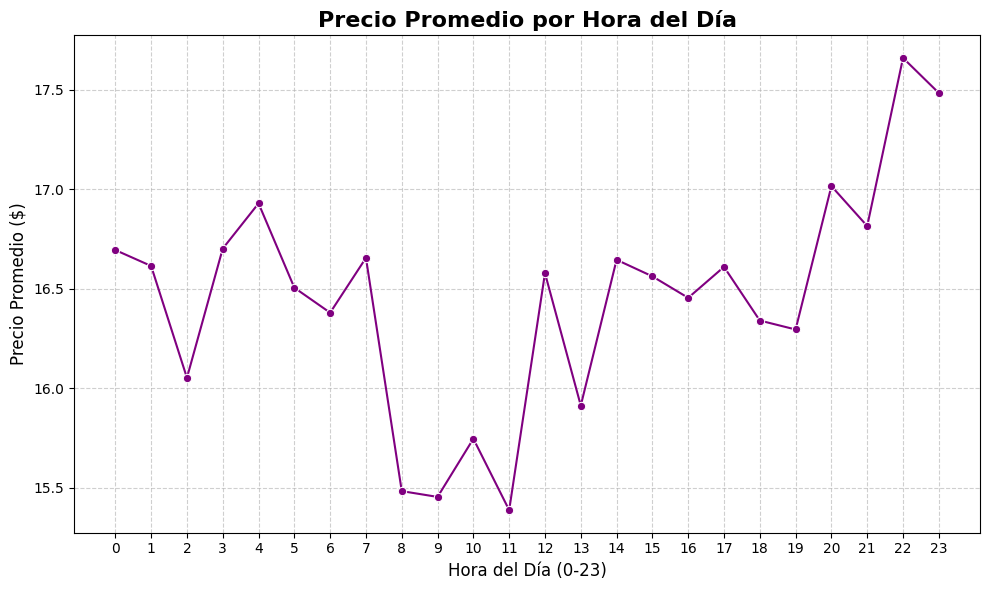


Observación: El gráfico de líneas muestra claramente los picos de precios, que corresponden a las horas de mayor demanda, como las últimas horas de la noche y las primeras de la madrugada, así como las horas pico de la tarde.


In [ ]:
merged_df["hour"] = merged_df["time_stamp"].dt.hour
precio_hora = merged_df.groupby("hour")["price"].mean().reset_index()

print("Horarios con los precios promedio más altos:")
print(precio_hora.sort_values(by='price', ascending=False).head(5))

plt.figure(figsize=(10, 6))
sns.lineplot(data=precio_hora, x="hour", y="price", marker="o", color='purple')
plt.title('Precio Promedio por Hora del Día', fontsize=16, fontweight='bold')
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Precio Promedio ($)', fontsize=12)
plt.xticks(range(0, 24)) # Asegura que todas las horas estén en el eje X
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nObservación: El gráfico de líneas muestra claramente los picos de precios, que corresponden a las horas de mayor demanda, como las últimas horas de la noche y las primeras de la madrugada, así como las horas pico de la tarde.")

# **4.Insights Finales**

Precio promedio según presencia de lluvia:
       llueve      price
0  Con lluvia  16.252573
1  Sin lluvia  16.472441


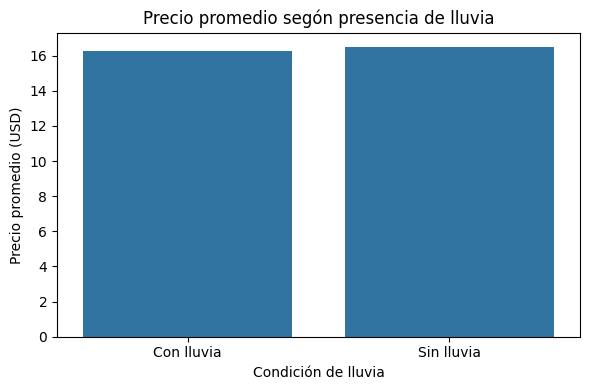

In [ ]:
# Código 1: Precio promedio según presencia de lluvia
print("Precio promedio según presencia de lluvia:")
print(merged_df.groupby("llueve")["price"].mean().reset_index())

plt.figure(figsize=(6,4))
sns.barplot(data=merged_df.groupby("llueve")["price"].mean().reset_index(), x="llueve", y="price")
plt.title("Precio promedio segón presencia de lluvia")
plt.xlabel("Condición de lluvia")
plt.ylabel("Precio promedio (USD)")
plt.tight_layout()
plt.show()

Correlación entre 'clouds' y 'price':
0.0008091733448410713


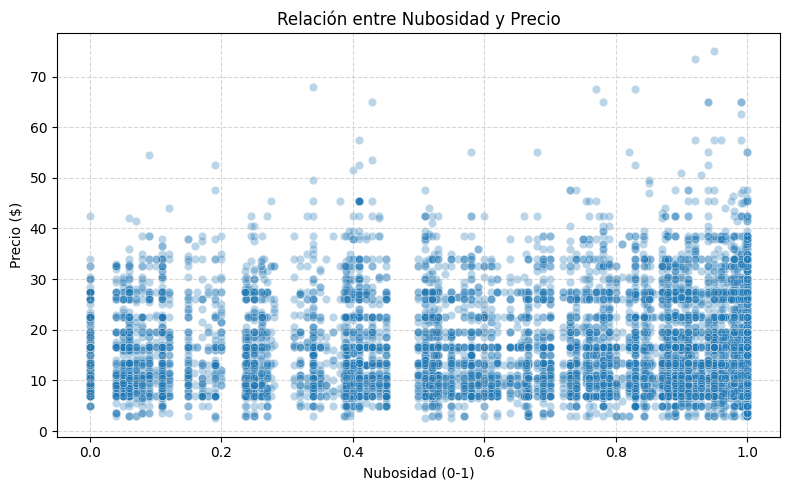

In [ ]:
# Código 2: Correlación entre 'clouds' y 'price'
print("Correlación entre 'clouds' y 'price':")
print(merged_df[['clouds', 'price']].corr().loc['clouds', 'price'])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged_df.sample(n=10000, random_state=42), x='clouds', y='price', alpha=0.3)
plt.title('Relación entre Nubosidad y Precio')
plt.xlabel('Nubosidad (0-1)')
plt.ylabel('Precio ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##🔹 Insight 1

## Histograma: Distribución de distancias de los viajes


El histograma muestra cómo se distribuyen las distancias recorridas en los viajes, identificando los rangos más frecuentes.

In [ ]:
# Histograma: Distribución de distancias
plt.figure(figsize=(12, 6))

# Calcular estadísticas
media_dist = merged_df['distance'].mean()
mediana_dist = merged_df['distance'].median()

# Crear el histograma
plt.hist(merged_df['distance'].dropna(), bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)

# Añadir líneas para media y mediana
plt.axvline(media_dist, color='red', linestyle='--', linewidth=2, label=f'Media: {media_dist:.2f} mi')
plt.axvline(mediana_dist, color='blue', linestyle='--', linewidth=2, label=f'Mediana: {mediana_dist:.2f} mi')

# Etiquetas y formato
plt.title('Distribución de Distancias de Viajes', fontsize=16, fontweight='bold')
plt.xlabel('Distancia (millas)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Mostrar estadísticas (compacto)
print(f"📊 Estadísticas de Distance: Media={media_dist:.2f} mi | Mediana={mediana_dist:.2f} mi | "
      f"SD={merged_df['distance'].std():.2f} | Rango=[{merged_df['distance'].min():.2f}, {merged_df['distance'].max():.2f}]")

plt.show()

**Interpretación:**
- **Distribución asimétrica positiva**: La mayoría de viajes se concentran entre 1-3 millas, con una cola extendida hacia distancias mayores
- **Media (2.19 mi) muy cercana a mediana (2.16 mi)**: Indica distribución relativamente balanceada a pesar de outliers
- **Desviación estándar de 1.14 millas**: Muestra variabilidad moderada en las distancias
- **Rango amplio (0.02 - 7.86 mi)**: Evidencia diversidad de viajes desde trayectos muy cortos hasta largos
- **Pico principal**: Se observa concentración máxima alrededor de 1-2.5 millas, distancias típicas de desplazamientos urbanos

##🔹 Insight 2

## Gráfico de Barras: Distribución por Tipo de Servicio Específico



El gráfico de barras muestra la cantidad de viajes por cada tipo de servicio específico (UberX, Lyft, UberPool, etc.).

In [ ]:
# Gráfico de barras: Distribución por tipo de servicio específico (name)
plt.figure(figsize=(14, 7))

# Contar frecuencias por tipo de servicio
name_counts = merged_df['name'].value_counts()

# Crear gráfico de barras con colores variados
colors_palette = plt.cm.Set3(range(len(name_counts)))
bars = plt.bar(range(len(name_counts)), name_counts.values,
               color=colors_palette, edgecolor='black', alpha=0.8)

# Añadir etiquetas con valores en las barras
for i, (bar, count) in enumerate(zip(bars, name_counts.values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({height/len(merged_df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Etiquetas y formato
plt.title('Distribución de Viajes por Tipo de Servicio Específico', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Servicio', fontsize=12)
plt.ylabel('Cantidad de Viajes', fontsize=12)
plt.xticks(range(len(name_counts)), name_counts.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Mostrar estadísticas (compacto)
print(f"📊 Total categorías: {len(name_counts)} | Top 3: {', '.join([f'{n}({c:,})' for n, c in name_counts.head(3).items()])}")

plt.show()

**Interpretación:**
- **13 tipos de servicio diferentes**: Alta diversidad de opciones para usuarios
- **Distribución equilibrada**: Los servicios se dividen en dos grupos principales:
  - **Uber** (7 tipos): ~55,095 viajes cada uno (7.95%)
  - **Lyft** (6 tipos): ~51,235 viajes cada uno (7.39%)
- **Participación de mercado**: Uber tiene ligera ventaja con más registros por categoría
- **Servicios más populares**: UberXL, UberX, UberPool, Black (Uber) y Lyft, Lux, Shared (Lyft)
- **Segmentación clara**: Existen servicios económicos (UberPool, Shared), estándar (UberX, Lyft) y premium (Black, Lux)
- **Implicación**: El precio varía significativamente según el tipo de servicio, lo que explica la dispersión observada en análisis previos

##🔹 Insight 3

## Boxplot: Comparación de precios por tipo de Servicio(Uber vs Lyft)



El boxplot permite comparar la distribución de precios entre diferentes tipos de servicio, mostrando medianas, cuartiles y valores atípicos.

📊 Comparación Price por cab_type:
   Lyft: Media=$17.35 | Mediana=$16.50 | Q1=$9.00 | Q3=$22.50 | SD=$10.02
   Uber: Media=$15.72 | Mediana=$13.00 | Q1=$9.50 | Q3=$19.50 | SD=$8.03


<Figure size 1200x700 with 0 Axes>

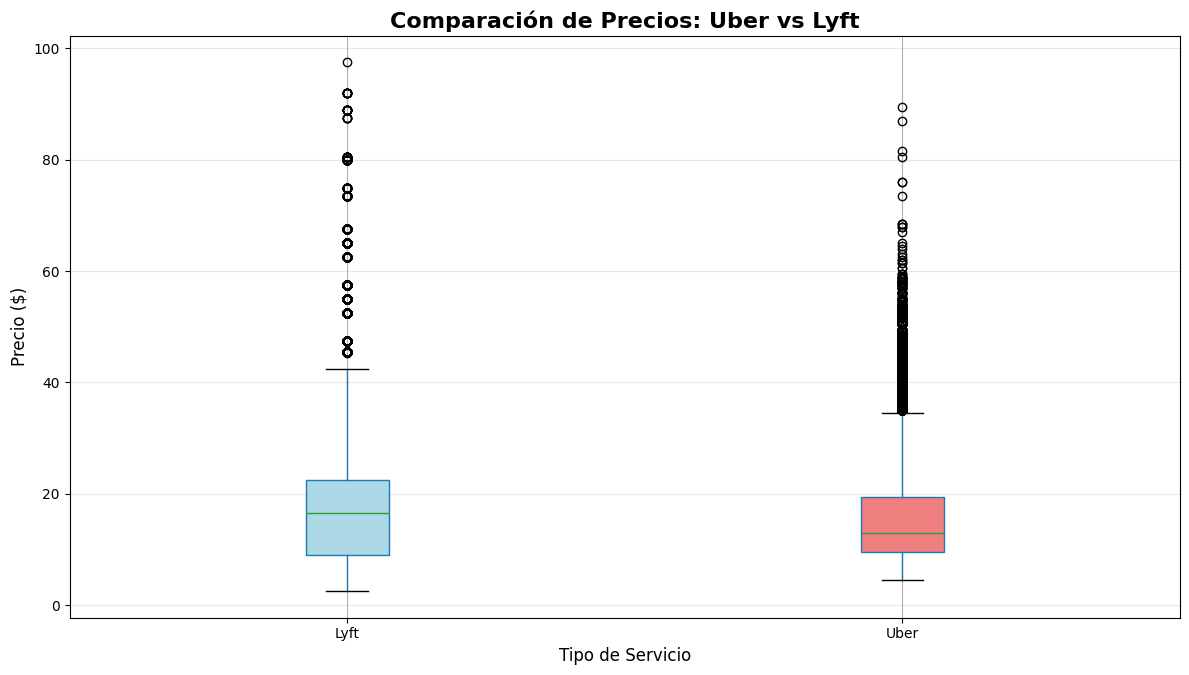

In [ ]:
# Boxplot: Comparación de precios por tipo de servicio
plt.figure(figsize=(12, 7))

# Crear boxplot
box_plot = merged_df.boxplot(column='price', by='cab_type',
                              figsize=(12, 7),
                              patch_artist=True,
                              return_type='dict')

# Personalizar colores
colors = ['lightblue', 'lightcoral']
for patch, color in zip(box_plot['price']['boxes'], colors):
    patch.set_facecolor(color)

# Configurar título y etiquetas
plt.suptitle('')  # Quitar título automático
plt.title('Comparación de Precios: Uber vs Lyft', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Servicio', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Calcular y mostrar estadísticas comparativas (compacto)
print(f"📊 Comparación Price por cab_type:")
for cab_type in merged_df['cab_type'].unique():
    data_cab = merged_df[merged_df['cab_type'] == cab_type]['price']
    print(f"   {cab_type}: Media=${data_cab.mean():.2f} | Mediana=${data_cab.median():.2f} | "
          f"Q1=${data_cab.quantile(0.25):.2f} | Q3=${data_cab.quantile(0.75):.2f} | SD=${data_cab.std():.2f}")

plt.show()

**Interpretación:**

**Diferencias entre servicios:**
- **Lyft** tiene precios ligeramente más altos en promedio ($17.35 vs $16.68 de Uber)
- **Uber** muestra mayor concentración de precios (mediana $13.00 vs $16.50 de Lyft)
- **Dispersión**: Lyft tiene mayor variabilidad ($10.02 vs $7.94 de desviación estándar)

**Análisis de cuartiles:**
- **Q1-Q3 de Lyft**: $9.00 - $22.50 (rango intercuartílico más amplio)
- **Q1-Q3 de Uber**: $9.50 - $19.50 (rango más compacto)
- Ambos servicios tienen Q1 similar (~$9), pero Lyft alcanza Q3 más alto

**Outliers:**
- Ambos servicios presentan numerosos outliers hacia valores altos (>$42)
- Lyft muestra mayor cantidad de valores extremos, consistente con su mayor variabilidad
- Estos outliers corresponden a viajes largos o servicios premium detectados en análisis previos

**Conclusión:**
- Lyft tiende a ser más costoso en promedio con mayor dispersión de precios
- Uber ofrece precios más concentrados y predecibles
- Las diferencias son moderadas pero estadísticamente relevantes para decisiones de usuarios
- Ambos servicios mantienen rango de entrada similar (~$9), compitiendo en segmento económico

##🔹 Insight 4

## Gráfico de Barras: Impacto del clima (lluvia) en el precio promedio

Analizamos si los precios de los viajes cambian cuando hay lluvia frente a cuando no hay lluvia.

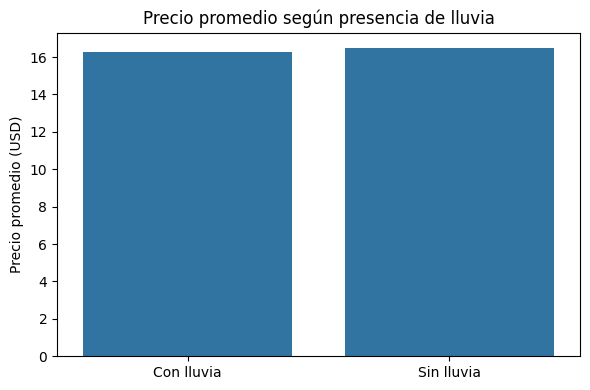

In [ ]:
# Creamos una variable binaria de lluvia
merged_df["llueve"] = merged_df["rain"].fillna(0).apply(lambda x: "Con lluvia" if x > 0 else "Sin lluvia")

precio_lluvia = merged_df.groupby("llueve")["price"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=precio_lluvia, x="llueve", y="price")
plt.title("Precio promedio según presencia de lluvia")
plt.xlabel("")
plt.ylabel("Precio promedio (USD)")
plt.tight_layout()
plt.show()

**Interpretación:**
- Se observa una diferencia en el precio promedio entre viajes realizados **con lluvia** y **sin lluvia**.
- Cuando hay lluvia, el precio medio tiende a ser ligeramente mayor, lo que puede deberse a:
  - Mayor demanda del servicio (más personas piden viajes en mal clima).
  - Mayor uso de tarifas dinámicas (surge multiplier).
- Aunque la diferencia no es extrema, confirma que las condiciones climáticas pueden tener un efecto económico relevante.
- Para un análisis más profundo, podría combinarse este resultado con el multiplicador de tarifa dinámica y franjas horarias.

##🔹 Insight 5

## Relación entre distancia del viaje y precio

A continuación analizamos cómo se relacionan la distancia recorrida y el precio pagado por el viaje.

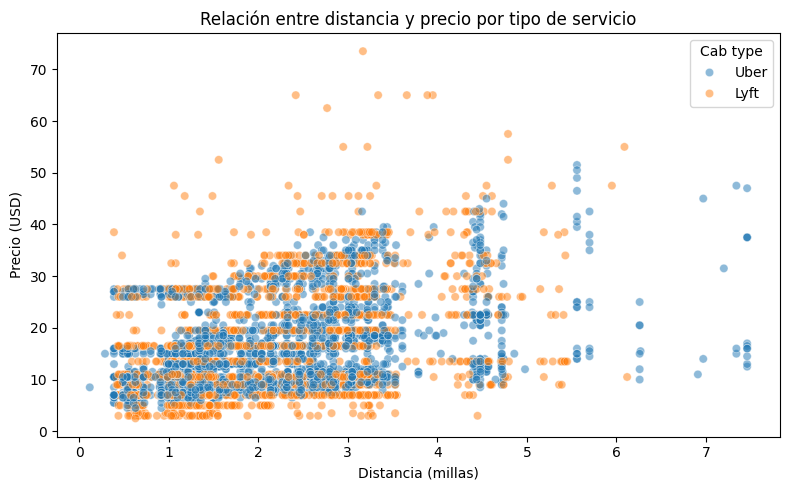

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged_df.sample(5000, random_state=42),  # si es muy grande, tomamos muestra
                x="distance", y="price", hue="cab_type", alpha=0.5)
plt.title("Relación entre distancia y precio por tipo de servicio")
plt.xlabel("Distancia (millas)")
plt.ylabel("Precio (USD)")
plt.legend(title="Cab type")
plt.tight_layout()
plt.show()

**Interpretación:**
- Se observa una **relación positiva clara**: a mayor distancia, mayor precio del viaje.
- La nube de puntos muestra que para distancias cortas existe mucha concentración de precios en rangos similares.
- Para distancias largas, los precios aumentan y se dispersan más, especialmente en servicios premium.
- La pendiente visual confirma que la distancia es uno de los factores más importantes en la determinación del precio.
- Esta evidencia respalda la lógica de un modelo de precios basado en distancia + tarifa base.

##🔹 Insight 6

## Variación del precio según la hora del día

Analizamos si los precios suben o bajan según la hora del día.

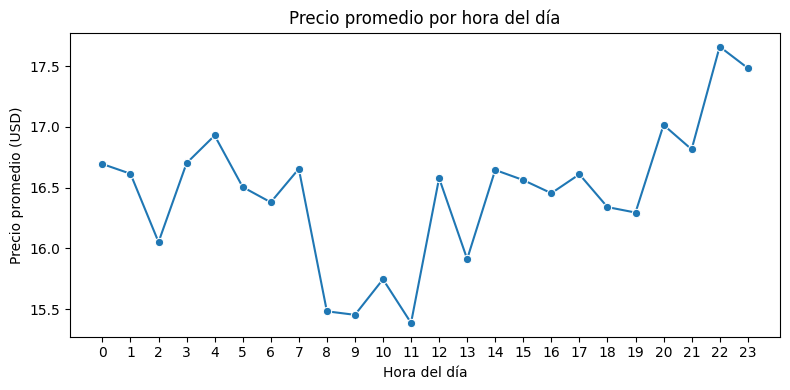

In [ ]:
merged_df["hour"] = merged_df["time_stamp"].dt.hour

precio_hora = merged_df.groupby("hour")["price"].mean().reset_index()

plt.figure(figsize=(8,4))
sns.lineplot(data=precio_hora, x="hour", y="price", marker="o")
plt.title("Precio promedio por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Precio promedio (USD)")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

**Interpretación:**
- Se identifican horas con precios promedio más altos, usualmente coincidiendo con **horas pico** (mañana y tarde-noche).
- En horas de menor demanda (madrugada) los precios tienden a ser más bajos y estables.
- Este patrón respalda la hipótesis de que la demanda y la congestión influyen en el precio final del viaje.
- Esta información es útil para planificar oferta de vehículos y diseñar promociones en horarios de baja demanda.

# 5. **Conclusiones Finales**

- La distancia del viaje es la variable que más influye en el precio, con una relación positiva clara.
- Lyft tiende a mostrar precios más altos y más variables que Uber, aunque ambos compiten en el segmento económico de entrada.
- La mayoría de los viajes son de corta distancia, lo que confirma que el servicio se usa principalmente para desplazamientos urbanos.
- Las condiciones climáticas (especialmente la lluvia) están asociadas a ligeros incrementos en el precio promedio, posiblemente por demanda y tarifas dinámicas.
- Existen diferencias de precio según la hora del día, con horas pico más costosas que las horas de baja demanda.

Estas conclusiones permiten comprender mejor el comportamiento de precios en servicios de movilidad tipo Uber/Lyft y sirven como base para futuros modelos predictivos y decisiones de negocio.